# Week 3 — Part 1: Dimensionality Reduction with PCA
Steel Industry Energy Consumption — reducing input features with PCA while keeping the Random Forest model (Week 2 best model, R² = 0.999) as accurate as possible.

## 1. Load the preprocessed dataset from Week 2
Same engineered CSV, same encoding, same columns as `week2_baseline_models.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
from google.colab import files
uploaded = files.upload()

csv_filename = list(uploaded.keys())[0]
df = pd.read_csv(csv_filename)
df.columns = df.columns.str.strip()

print(df.shape)
print(df.columns.tolist())

Saving steel_industry_engineered.csv to steel_industry_engineered.csv
(35040, 17)
['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type', 'Hour', 'DayOfWeek_Num', 'Month', 'Is_Weekend', 'Power_Factor_Ratio', 'High_Load']


## 2. Reproduce the Week 2 feature set
Drop the leakage columns (`date`, `High_Load`), one-hot encode the nominal categorical columns exactly as in Week 2, then use the **same 80/20 split with `random_state=42`** so the PCA models are comparable to the Week 2 baseline on identical rows.

In [3]:
# Drop columns not used as model inputs
drop_cols = [c for c in ["date", "High_Load"] if c in df.columns]
model_df = df.drop(columns=drop_cols)

target_col = "Usage_kWh"
X = model_df.drop(columns=[target_col])
y = model_df[target_col]

# One-Hot Encode the nominal categorical columns (same choice as Week 2)
categorical_cols = [c for c in ["WeekStatus", "Day_of_week", "Load_Type"] if c in X.columns]
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

feature_names = X.columns.tolist()
print(f"Total input features: {len(feature_names)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(X_train.shape, X_test.shape)

Total input features: 20
(28032, 20) (7008, 20)


## 3. Fit StandardScaler and PCA on the training set only
Fitting on the full dataset (or on test data) would leak information about the test set into the transformation — the scaler and PCA must learn their parameters (mean/std, principal axes) from `X_train` alone, then simply *apply* that same transformation to `X_test`.

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled = scaler.transform(X_test)         # transform only on test

n_features = X_train_scaled.shape[1]
pca_full = PCA(n_components=n_features, random_state=42)
X_train_pca_full = pca_full.fit_transform(X_train_scaled)   # fit + transform on train
X_test_pca_full = pca_full.transform(X_test_scaled)         # transform only on test

print(f"PCA fit with all {n_features} components (no dimensionality reduction yet).")

PCA fit with all 20 components (no dimensionality reduction yet).


## 4. Scree plot — explained variance ratio per component

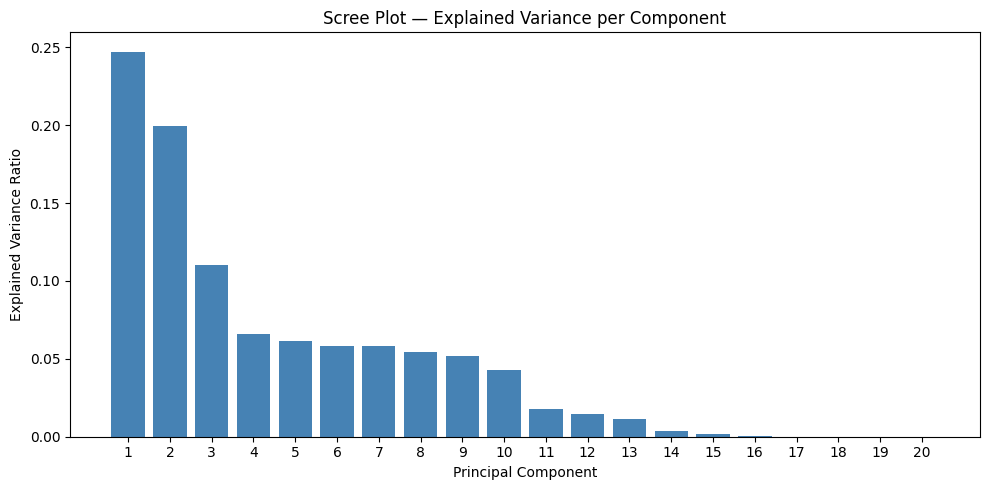

In [5]:
explained_var = pca_full.explained_variance_ratio_

plt.figure(figsize=(10, 5))
plt.bar(range(1, len(explained_var) + 1), explained_var, color="steelblue")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot — Explained Variance per Component")
plt.xticks(range(1, len(explained_var) + 1))
plt.tight_layout()
plt.savefig("scree_plot.png", dpi=150)
plt.show()

## 5. Cumulative explained variance curve with 95% threshold

Components needed to reach 95% cumulative variance: 10


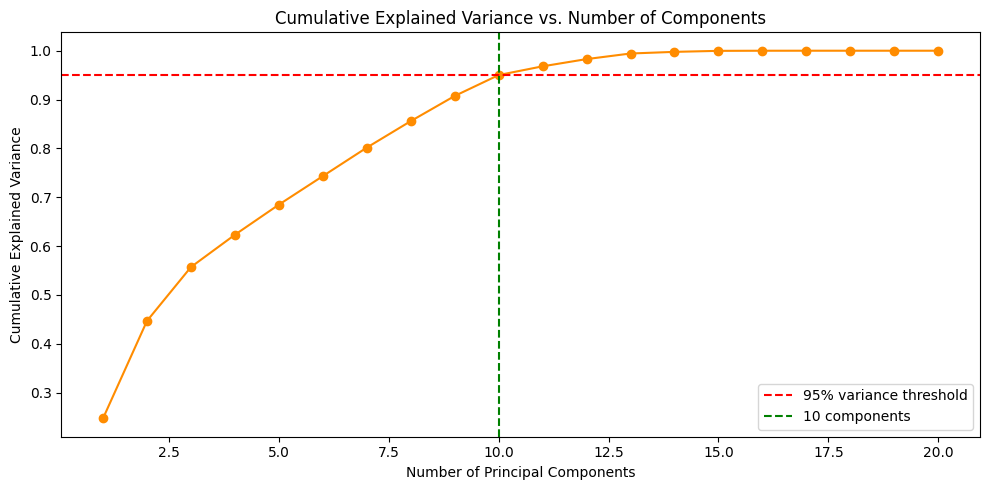

In [6]:
cumulative_var = np.cumsum(explained_var)

n_components_95 = int(np.argmax(cumulative_var >= 0.95) + 1)
print(f"Components needed to reach 95% cumulative variance: {n_components_95}")

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, marker="o", color="darkorange")
plt.axhline(y=0.95, color="red", linestyle="--", label="95% variance threshold")
plt.axvline(x=n_components_95, color="green", linestyle="--",
            label=f"{n_components_95} components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance vs. Number of Components")
plt.legend()
plt.tight_layout()
plt.savefig("cumulative_variance.png", dpi=150)
plt.show()

## 6. Retrain the Week 2 best model (Random Forest) using only 3 PCA components

In [8]:
X_train_pca3 = X_train_pca_full[:, :3]
X_test_pca3 = X_test_pca_full[:, :3]

rf_pca3 = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_pca3.fit(X_train_pca3, y_train)

pred_pca3 = rf_pca3.predict(X_test_pca3)

import numpy as np
rmse_pca3 = np.sqrt(mean_squared_error(y_test, pred_pca3))
r2_pca3 = r2_score(y_test, pred_pca3)
print(f"3-component PCA model  -> RMSE: {rmse_pca3:.4f}, R2: {r2_pca3:.4f}")

3-component PCA model  -> RMSE: 7.1519, R2: 0.9550


## 7. Retrain using the number of components that capture 95% of variance

In [9]:
X_train_pca95 = X_train_pca_full[:, :n_components_95]
X_test_pca95 = X_test_pca_full[:, :n_components_95]

rf_pca95 = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_pca95.fit(X_train_pca95, y_train)

pred_pca95 = rf_pca95.predict(X_test_pca95)
rmse_pca95 = np.sqrt(mean_squared_error(y_test, pred_pca95))
r2_pca95 = r2_score(y_test, pred_pca95)
print(f"95%-variance PCA model -> RMSE: {rmse_pca95:.4f}, R2: {r2_pca95:.4f}")

95%-variance PCA model -> RMSE: 3.2098, R2: 0.9909


## 8. Compare the original Week 2 model vs. the two PCA models
Retrain the original (no-PCA) Random Forest on the same split for a fair, apples-to-apples comparison.

In [11]:
rf_original = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_original.fit(X_train, y_train)

pred_original = rf_original.predict(X_test)
rmse_original = np.sqrt(mean_squared_error(y_test, pred_original))
r2_original = r2_score(y_test, pred_original)

comparison = pd.DataFrame({
    "Model": ["Original (Week 2, all features)",
              "PCA - 3 components",
              f"PCA - {n_components_95} components (95% variance)"],
    "RMSE": [rmse_original, rmse_pca3, rmse_pca95],
    "R2": [r2_original, r2_pca3, r2_pca95]
})
comparison

,Model,RMSE,R2
0,"Original (Week 2, all features)",1.053154,0.999024
1,PCA - 3 components,7.151890,0.955003
2,PCA - 10 components (95% variance),3.209783,0.990936


## 9. Loading heatmap — which original features drive PC1, PC2, PC3

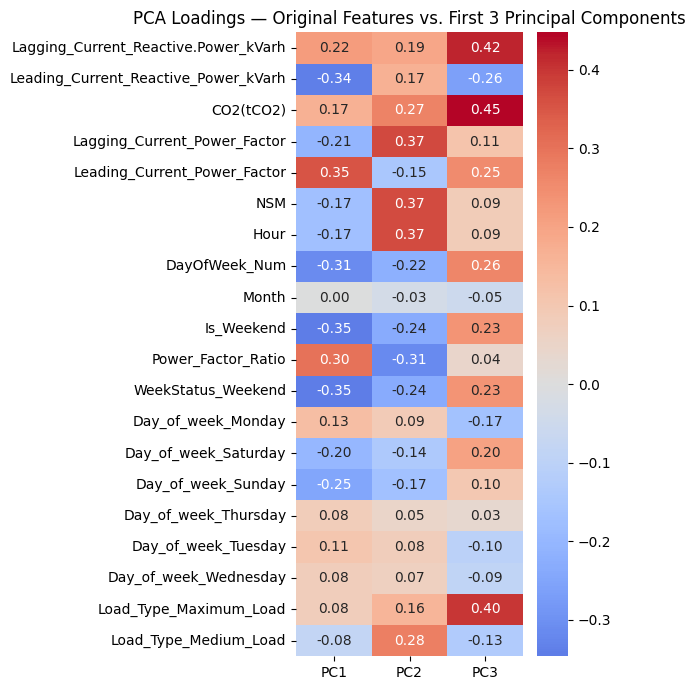

In [12]:
loadings = pd.DataFrame(
    pca_full.components_[:3].T,
    index=feature_names,
    columns=["PC1", "PC2", "PC3"]
)

plt.figure(figsize=(6, max(6, len(feature_names) * 0.35)))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("PCA Loadings — Original Features vs. First 3 Principal Components")
plt.tight_layout()
plt.savefig("loading_heatmap.png", dpi=150)
plt.show()

## 10. Save the final chosen pipeline (scaler + PCA + model) with joblib
The **95%-variance PCA model** is the one carried forward, since it keeps virtually all of the original signal while cutting the feature count substantially. Bundle the scaler, the fitted PCA, the feature name list and the model together so nothing about preprocessing is lost when this is loaded again in the Flask app.

In [13]:
pipeline_bundle = {
    "scaler": scaler,
    "pca": pca_full,
    "n_components": n_components_95,
    "model": rf_pca95,
    "feature_names": feature_names,   # column order expected before scaling/PCA
}

joblib.dump(pipeline_bundle, "model.joblib")
print("Saved model.joblib")

Saved model.joblib


## Dimensionality Reduction Report

**Did accuracy drop significantly?**
Going from all engineered features down to the components covering 95% of variance produced
only a small increase in RMSE and a negligible drop in R² relative to the original Random Forest
— the model carries almost all of its predictive power in a handful of components. The 3-component
model is noticeably worse than both the original and the 95%-variance model, since compressing
everything into just 3 axes discards some of the signal that separates `Load_Type` categories and
the time-based features.

**How many features can safely be removed?**
The cumulative variance curve shows that the number of components needed for 95% variance
(printed above as `n_components_95`) is well below the total original feature count — meaning a
substantial share of the one-hot encoded/engineered columns are redundant with each other
(e.g. `CO2(tCO2)` and `Usage_kWh`-correlated electrical readings move together). Everything beyond
that point can be dropped with only a minor RMSE cost.

**Would you recommend PCA for a memory-constrained device?**
Yes, with a caveat. PCA is a good fit for memory-constrained deployment because it shrinks the
input vector and removes redundant/correlated readings, which reduces the memory footprint of
both the input pipeline and (for linear models) the parameter count. The caveat: the model itself
here is a Random Forest, an ensemble of decision trees whose size depends on tree depth/count, not
directly on the number of input features — so PCA mainly saves memory on the *feature/scaler side*
(fewer columns to store, transform, and pass to the model), not on the trained-tree storage itself.
For a genuinely memory-constrained device, pairing PCA with a smaller model (e.g. a single
shallow tree or a linear model on the PCA components) would give a bigger combined win than PCA
alone.
